In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import time

from sipp import *
sys.path.append(os.path.abspath('../common'))
from DO_structs import *
from DO_graphics import *
from DO_searching import *

%matplotlib inline

# SIPP on the Arena Map (Random Obstacles)

In [3]:
# 1. Map (grid with static obstacles)
task_map = Map()
task_map.read_from_movingai_file("../maps/arena.map")

# 2. Control Set (for dynamic environment) 
env_cs = ControlSet()
env_cs.load_primitives("../data/control_set.txt")

# 3. Environmnet (both static and dynamic obstacles)
R = 1  # Ego-robot radius
environment = DynamicEnvironment(task_map, R)
# Load dynamic obstacle (<= 50) trajectories constructed from the env_cs primitive set
environment.load_obstacles_from_dir("../dynamic_obstacles/arena_random/dynamic_obstacle_*.txt", env_cs, max_items=50)
# Project obstacle trajectories onto the grid map while inflating them by the ego-robot's radius R.
# This compiles a sequence of safe time-occupancy intervals for every individual cell,
# which serves as the core input data structure for the SIPP algorithm.
environment.compile_safe_intervals()

In [4]:
# Ego-robot control set of primitives:
extended_cs = ControlSet()
extended_cs.load_primitives("../data/extended_set.txt")  # use extended one, for example

In [5]:
# Test case (start and goal states on the task_map)
start = DiscreteState(29, 32, -3)
goal = DiscreteState(12, 36, -6)

# Construct the search space by passing the following parameters:
# - start / goal: Boundary states of the query
# - start time: The exact tick when the ego-robot spawns (0.0)
# - extended_cs: The control set bundle used to build the ego-robot's trajectory
# - environment: The world model containing static grid maps and safe intervals
# - R=0, A=0: Target tolerances (spatial radius 'R' and angular deviation 'A' in discrete headings)
# - position_only=False: Enforces strict orientation constraints (respects both start and final theta). 
#                        If set to True, the planner would find a path between coordinate cells regardless of heading.
search_space = SIPPSearchSpace(start, 0.0, goal, extended_cs, environment, R=0, A=0, position_only=False)

# Execute the SIPP (A*) search algorithm
success, path, steps, cost, ast = astar(search_space)
success, steps, cost

(True, 323, np.float64(254.323081))

In [6]:
# Instantiate the ego-robot as a dynamic obstacle (as it shares the same underlying trajectory representation)
robot = DynamicObstacle(extended_cs).set_parametres(R, start.i, start.j, start.theta, path)

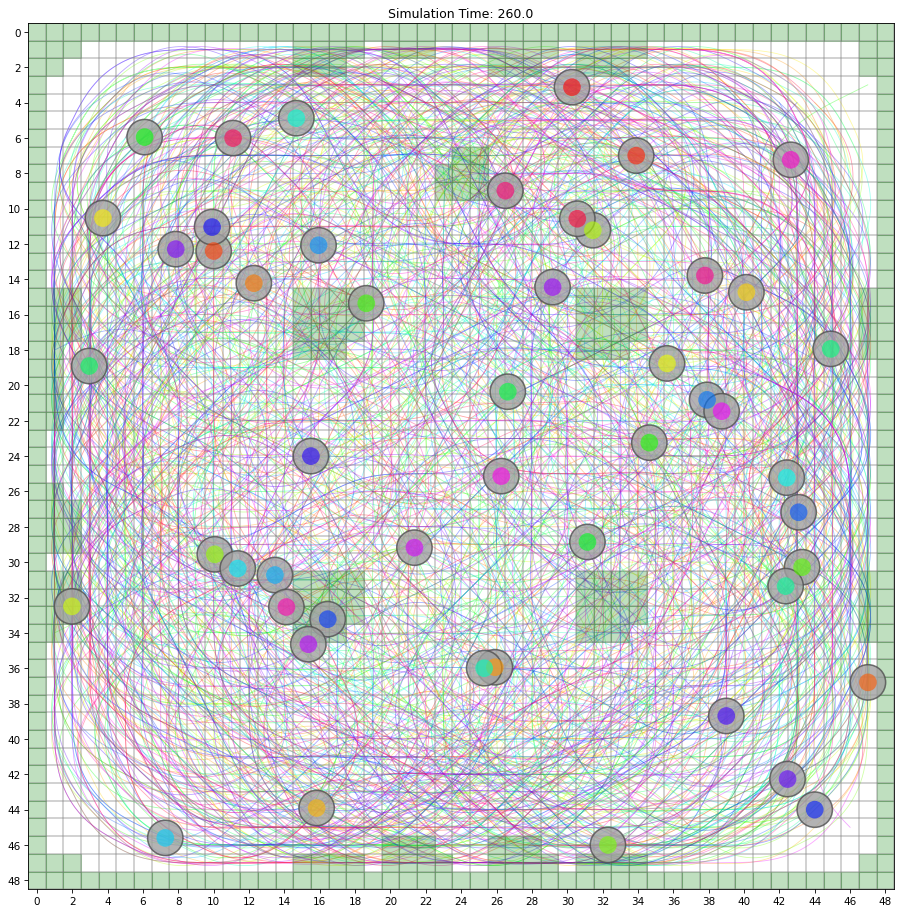

Saving GIF... Total frames compiled: 141
Simulation successfully saved to: ../media/path_arena_random_1.gif


In [7]:
# Proceed to visualization as usual
update_sim, save_sim = create_dynamic_visualizer(
    task_map=task_map,
    obstacle_set=environment.get_dynamic_obstacles_set(),
    show_path=True,
    fast_draw=False,
    make_gif=True,
    robot=robot,
    dpi=75,
    scale=1.5,
    robot_line_width=2.0,
    obs_line_width=0.8
)

max_time = 260.0
dt = 2
current_time = 0.0

while current_time <= max_time:
    update_sim(current_time)
    current_time += dt
    time.sleep(0.005)

save_sim("../media/path_arena_random_1.gif", fps=20)

# SIPP for $2^k$-Connectivity on an Empty Map (Circular Obstacles)

This section demonstrates pathfinding using the **SIPP** planner integrated with a dense **$2^k$-connectivity** lattice. Here, orientation constraints are relaxed, allowing for instantaneous heading changes at each vertex while strictly respecting dynamic safe intervals.

In [8]:
# 1. Map and Environment
task_map = Map()
task_map.read_from_movingai_file("../maps/empty_64_64.map")

R = 1  # robot radius
environment = DynamicEnvironment(task_map, R)
environment.load_obstacles_from_dir("../dynamic_obstacles/empty_64_64_circle/dynamic_obstacle_*.txt", env_cs, max_items=1000)
environment.compile_safe_intervals()

In [9]:
# 2. Control Set for 2^2-Connectivity
cs_2 = ControlSet().load_primitives("../data/primitives_2k_2.txt")

# NOTE: The heading parameter (theta) is ignored for 2^k connectivity because 
# it does not enforce physical orientation constraints (the search space tracks 
# coordinates only). We pass theta=0 as a dummy value for backward compatibility.
start = DiscreteState(24, 39, 0)
goal = DiscreteState(48, 9, 0)

search_space = SIPPSearchSpace(start, 0.0, goal, cs_2, environment, R=0, A=0)

In [10]:
success, path, steps, cost, ast = astar(search_space)
success, steps, cost

(True, 3277, np.float64(705.2847429999999))

In [11]:
# Instantiate the ego-robot using the 2^2 primitive set
robot = DynamicObstacle(cs_2).set_parametres(R, start.i, start.j, start.theta, path)

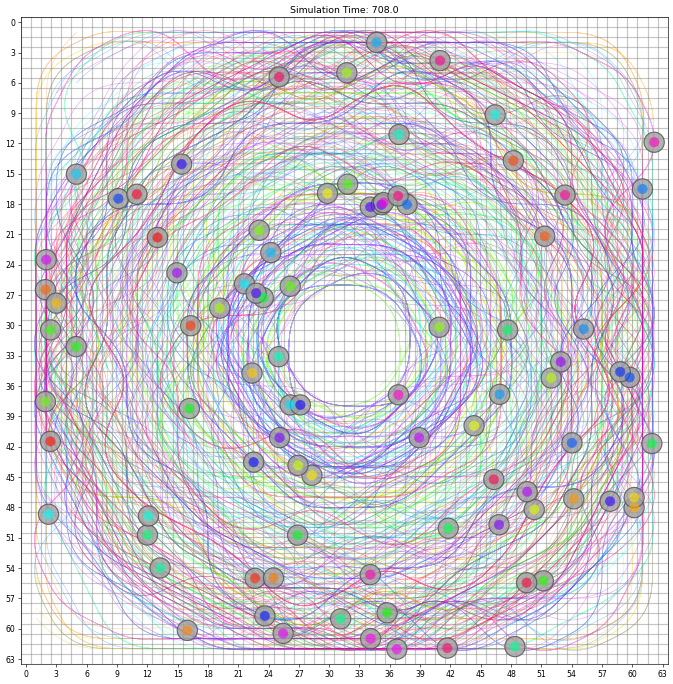

Saving GIF... Total frames compiled: 247
Simulation successfully saved to: ../media/path_empty_circle_1.gif


In [14]:
update_sim, save_sim = create_dynamic_visualizer(
    task_map=task_map,
    obstacle_set=environment.get_dynamic_obstacles_set(),
    show_path=True,
    fast_draw=False,
    make_gif=True,
    robot=robot,
    dpi=56,
    scale=1.5,
    robot_line_width=2.0,
    obs_line_width=0.8
)

max_time = 710.0
dt = 3
current_time = 0.0

while current_time <= max_time:
    update_sim(current_time)
    current_time += dt
    time.sleep(0.005)

save_sim("../media/path_empty_circle_1.gif", fps=20)